In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')


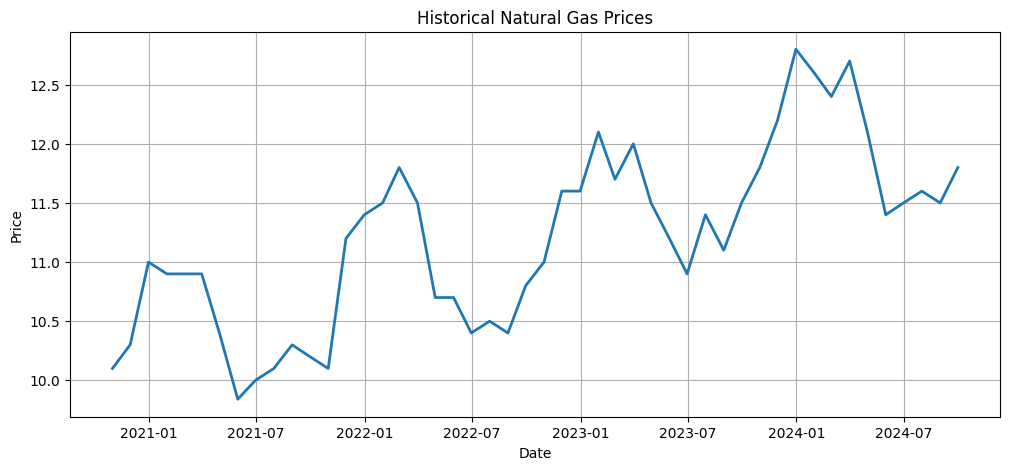

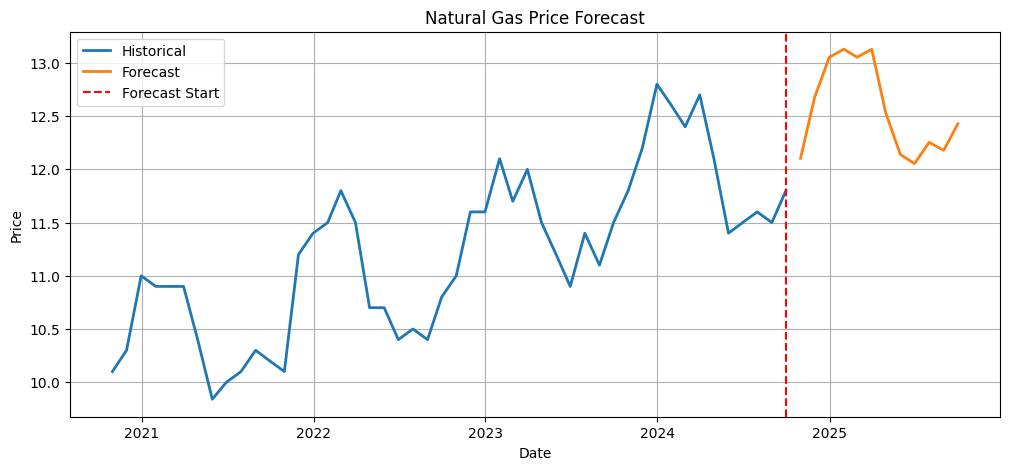

2022-06-15 : 10.55
2024-09-30 : 11.8
2025-04-15 : 12.83
2025-09-20 : 12.35


In [58]:
def load_data(filepath='Nat_Gas.csv'):
    df = pd.read_csv(filepath, parse_dates=['Dates'])
    df = df.sort_values('Dates').reset_index(drop=True)
    return df

plt.figure(figsize=(12,5))
plt.plot(df["Dates"], df["Prices"], linewidth=2)
plt.title("Historical Natural Gas Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()


model = ExponentialSmoothing(
    df["Prices"],
    trend="add",
    seasonal="add",
    seasonal_periods=12
)

fit = model.fit()


forecast = fit.forecast(12)

future_dates = pd.date_range(
    start=df["Dates"].iloc[-1] + pd.DateOffset(months=1),
    periods=12,
    freq="M"
)

forecast_df = pd.DataFrame({
    "Dates": future_dates,
    "Prices": forecast
})

# Combine historical and forecast
all_data = pd.concat([df, forecast_df], ignore_index=True)


plt.figure(figsize=(12,5))
plt.plot(df["Dates"], df["Prices"], label="Historical", linewidth=2)
plt.plot(forecast_df["Dates"], forecast_df["Prices"], label="Forecast", linewidth=2)
plt.axvline(df["Dates"].iloc[-1], color="red", linestyle="--", label="Forecast Start")
plt.legend()
plt.title("Natural Gas Price Forecast")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()


def estimate_price(date):

    date = pd.to_datetime(date)

    daily = all_data.set_index("Dates")["Prices"]

    daily = daily.reindex(
        pd.date_range(
            start=daily.index.min(),
            end=daily.index.max(),
            freq="D"
        )
    )

    daily = daily.interpolate(method="time")

    if date < daily.index.min() or date > daily.index.max():
        return "Date outside available range."

    return round(float(daily.loc[date]), 2)


print("2022-06-15 :", estimate_price("2022-06-15"))
print("2024-09-30 :", estimate_price("2024-09-30"))
print("2025-04-15 :", estimate_price("2025-04-15"))
print("2025-09-20 :", estimate_price("2025-09-20"))